In [ ]:
print("=" * 80)
print("🔧 SECTION 1: INSTALLATION AND SETUP")
print("=" * 80)

import subprocess
import sys

def install_packages():
    """Install all required packages for MolmoAct"""
    packages = [
        "torch>=2.0.0",
        "torchvision",
        "transformers==4.52",
        "accelerate",
        "einops",
        "Pillow",
        "numpy",
        "matplotlib",
        "requests",
        "scipy",
        "huggingface_hub",
    ]

    for package in packages:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

    print("✅ All packages installed successfully!")

install_packages()

print("\n" + "=" * 80)
print("📚 SECTION 2: IMPORTS AND CONFIGURATION")
print("=" * 80)

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from typing import List, Tuple, Dict, Optional, Union
import json
import time
from dataclasses import dataclass
import warnings
import re

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\n" + "=" * 80)
print("🤖 SECTION 3: MOLMOACT MODEL LOADER")
print("=" * 80)

@dataclass
class MolmoActConfig:
    """Configuration for MolmoAct model"""
    model_name: str = "allenai/MolmoAct-7B-D-0812"
    torch_dtype: str = "bfloat16"
    device_map: str = "auto"
    max_new_tokens: int = 256
    temperature: float = 0.0
    do_sample: bool = False

In [ ]:
class MolmoActModel:
    """
    MolmoAct Model Wrapper for Easy Inference

    This class provides a high-level interface for:
    - Loading and managing the model
    - Running inference with proper prompting
    - Parsing outputs (depth, trace, actions)
    - Batch processing
    """

    def __init__(self, config: Optional[MolmoActConfig] = None):
        self.config = config or MolmoActConfig()
        self.model = None
        self.processor = None
        self._loaded = False

    def load(self) -> None:
        """Load the MolmoAct model and processor"""
        if self._loaded:
            print("⚠️ Model already loaded!")
            return

        print(f"🔄 Loading MolmoAct model: {self.config.model_name}")
        print("   This may take a few minutes on first run...")

        from transformers import AutoModelForImageTextToText, AutoProcessor

        dtype = getattr(torch, self.config.torch_dtype)

        print("   📥 Loading model weights...")
        self.model = AutoModelForImageTextToText.from_pretrained(
            self.config.model_name,
            trust_remote_code=True,
            torch_dtype=dtype,
            device_map=self.config.device_map,
        )

        print("   📥 Loading processor...")
        try:
            self.processor = AutoProcessor.from_pretrained(
                self.config.model_name,
                trust_remote_code=True,
            )
            if hasattr(self.processor, 'tokenizer'):
                self.processor.tokenizer.padding_side = "left"
        except TypeError as e:
            if "prompt_templates" in str(e):
                print("   ⚠️ Handling custom processor configuration...")
                from transformers.dynamic_module_utils import get_class_from_dynamic_module

                processor_class = get_class_from_dynamic_module(
                    "processing_molmoact.MolmoActProcessor",
                    self.config.model_name,
                    trust_remote_code=True,
                )

                from transformers import AutoTokenizer, AutoImageProcessor

                tokenizer = AutoTokenizer.from_pretrained(
                    self.config.model_name,
                    trust_remote_code=True,
                    padding_side="left",
                )

                image_processor = AutoImageProcessor.from_pretrained(
                    self.config.model_name,
                    trust_remote_code=True,
                )

                self.processor = processor_class(
                    image_processor=image_processor,
                    tokenizer=tokenizer,
                )
            else:
                raise e

        self._loaded = True
        print("✅ Model loaded successfully!")
        self._print_model_info()

    def _print_model_info(self) -> None:
        """Print model information"""
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"\n📊 Model Statistics:")
        print(f"   Total Parameters: {total_params / 1e9:.2f}B")
        print(f"   Trainable Parameters: {trainable_params / 1e9:.2f}B")
        print(f"   Model dtype: {next(self.model.parameters()).dtype}")

    def build_prompt(self, instruction: str) -> str:
        """
        Build the reasoning prompt for MolmoAct

        The prompt structure is crucial for MolmoAct to generate:
        1. Depth perception tokens
        2. Visual trajectory trace
        3. Action predictions
        """
        prompt = (
            f"The task is {instruction}. "
            "What is the action that the robot should take. "
            f"To figure out the action that the robot should take to {instruction}, "
            "let's think through it step by step. "
            "First, what is the depth map for the first image? "
            "Second, what is the trajectory of the end effector in the first image? "
            "Based on the depth map of the first image and the trajectory of the end effector in the first image, "
            "along with other images from different camera views as additional information, "
            "what is the action that the robot should take?"
        )
        return prompt

In [ ]:
    @torch.inference_mode()
    def generate(
        self,
        images: List[Image.Image],
        instruction: str,
        max_new_tokens: Optional[int] = None,
    ) -> Dict:
        """
        Generate action reasoning from images and instruction

        Args:
            images: List of PIL Images
            instruction: Task instruction
            max_new_tokens: Override default max tokens

        Returns:
            Dictionary containing:
            - text: Generated reasoning text
            - depth: Parsed depth tokens
            - trace: Parsed visual trace coordinates
            - action: Parsed action values
        """
        if not self._loaded:
            raise RuntimeError("Model not loaded! Call .load() first.")

        prompt = self.build_prompt(instruction)
        max_tokens = max_new_tokens or self.config.max_new_tokens

        text = self.processor.apply_chat_template(
            [{"role": "user", "content": [dict(type="text", text=prompt)]}],
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = self.processor(
            images=[images],
            text=text,
            padding=True,
            return_tensors="pt",
        )

        inputs = {k: v.to(self.model.device) for k, v in inputs.items()}

        with torch.autocast("cuda", enabled=True, dtype=torch.bfloat16):
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=max_tokens,
                do_sample=self.config.do_sample,
            )

        generated_tokens = generated_ids[:, inputs['input_ids'].size(1):]
        generated_text = self.processor.batch_decode(
            generated_tokens,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]

        result = {
            "text": generated_text,
            "depth": self._safe_parse_depth(generated_text),
            "trace": self._safe_parse_trace(generated_text),
            "action": self._safe_parse_action(generated_text, unnorm_key="molmoact"),
            "action_raw": self._safe_parse_action(generated_text, unnorm_key=None),
        }

        return result

    def _safe_parse_depth(self, text: str) -> List[str]:
        """Safely parse depth tokens from generated text"""
        try:
            if hasattr(self.model, 'parse_depth'):
                return self.model.parse_depth(text)
        except Exception:
            pass

        depth_pattern = r'<DEPTH_START>.*?<DEPTH_END>'
        matches = re.findall(depth_pattern, text, re.DOTALL)
        return matches if matches else []

    def _safe_parse_trace(self, text: str) -> List[List[List[int]]]:
        """Safely parse visual trace coordinates from generated text"""
        try:
            if hasattr(self.model, 'parse_trace'):
                return self.model.parse_trace(text)
        except Exception:
            pass

        coord_pattern = r'\[(\d+),\s*(\d+)\]|\((\d+),\s*(\d+)\)'
        matches = re.findall(coord_pattern, text)

        traces = []
        current_trace = []
        for match in matches:
            x = int(match[0] or match[2])
            y = int(match[1] or match[3])
            if 0 <= x <= 256 and 0 <= y <= 256:
                current_trace.append([x, y])

        if current_trace:
            traces.append(current_trace)

        return traces

    def _safe_parse_action(self, text: str, unnorm_key: Optional[str] = None) -> List[List[float]]:
        """Safely parse action values from generated text"""
        try:
            if hasattr(self.model, 'parse_action'):
                return self.model.parse_action(text, unnorm_key=unnorm_key)
        except Exception:
            pass

        float_pattern = r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?'
        all_floats = re.findall(float_pattern, text)

        actions = []
        floats = [float(f) for f in all_floats]

        for i in range(len(floats) - 6):
            potential_action = floats[i:i+7]
            if all(-5 < v < 5 for v in potential_action[:6]):
                actions.append(potential_action)
                break

        return actions

    def batch_generate(
        self,
        batch_data: List[Tuple[List[Image.Image], str]],
        progress: bool = True
    ) -> List[Dict]:
        """
        Process multiple observations in batch
        """
        results = []
        total = len(batch_data)

        for i, (images, instruction) in enumerate(batch_data):
            if progress:
                print(f"\r🔄 Processing {i+1}/{total}...", end="", flush=True)

            result = self.generate(images, instruction)
            results.append(result)

        if progress:
            print(f"\r✅ Processed {total} observations!")

        return results

print("\n" + "=" * 80)
print("🎨 SECTION 4: VISUALIZATION UTILITIES")
print("=" * 80)

In [ ]:
class MolmoActVisualizer:
    """Visualization utilities for MolmoAct outputs"""

    def __init__(self, figsize: Tuple[int, int] = (12, 8)):
        self.figsize = figsize
        self.colors = plt.cm.viridis(np.linspace(0, 1, 10))

    def plot_trace(
        self,
        image: Image.Image,
        trace: List[List[int]],
        title: str = "Visual Reasoning Trace",
        save_path: Optional[str] = None
    ) -> None:
        """Plot visual trace overlaid on image"""
        fig, ax = plt.subplots(figsize=self.figsize)

        img_array = np.array(image)
        ax.imshow(img_array)

        if trace and len(trace) > 0:
            h, w = img_array.shape[:2]
            trace_array = np.array(trace)

            x_coords = trace_array[:, 0] * w / 256
            y_coords = trace_array[:, 1] * h / 256

            ax.plot(x_coords, y_coords, 'w-', linewidth=2, alpha=0.7)
            ax.plot(x_coords, y_coords, 'c-', linewidth=1, alpha=0.9)

            for i, (x, y) in enumerate(zip(x_coords, y_coords)):
                color_idx = int(i * 9 / max(len(x_coords) - 1, 1))
                ax.scatter(x, y, c=[self.colors[color_idx]], s=100,
                          edgecolors='white', linewidths=2, zorder=5)
                ax.annotate(f'{i+1}', (x, y), textcoords="offset points",
                           xytext=(5, 5), fontsize=10, color='white',
                           fontweight='bold')

            ax.scatter(x_coords[0], y_coords[0], c='lime', s=200,
                      marker='o', edgecolors='white', linewidths=3,
                      zorder=6, label='Start')
            ax.scatter(x_coords[-1], y_coords[-1], c='red', s=200,
                      marker='X', edgecolors='white', linewidths=3,
                      zorder=6, label='End')

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        ax.legend(loc='upper right')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"💾 Saved visualization to {save_path}")

        plt.show()

    def plot_action(
        self,
        action: List[float],
        action_labels: Optional[List[str]] = None,
        title: str = "Predicted Robot Action",
        save_path: Optional[str] = None
    ) -> None:
        """Plot action values as a bar chart"""
        if action_labels is None:
            action_labels = [
                'Δx (forward)', 'Δy (left)', 'Δz (up)',
                'Rx (roll)', 'Ry (pitch)', 'Rz (yaw)',
                'Gripper'
            ]

        fig, ax = plt.subplots(figsize=(10, 5))

        colors = ['#3498db', '#3498db', '#3498db',
                  '#e74c3c', '#e74c3c', '#e74c3c',
                  '#2ecc71']

        x = np.arange(len(action))
        bars = ax.bar(x, action, color=colors, edgecolor='white', linewidth=1.5)

        for bar, val in zip(bars, action):
            height = bar.get_height()
            ax.annotate(f'{val:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3 if height >= 0 else -12),
                       textcoords="offset points",
                       ha='center', va='bottom' if height >= 0 else 'top',
                       fontsize=9, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(action_labels, rotation=45, ha='right')
        ax.set_ylabel('Value', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(axis='y', alpha=0.3)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#3498db', label='Position'),
            Patch(facecolor='#e74c3c', label='Rotation'),
            Patch(facecolor='#2ecc71', label='Gripper')
        ]
        ax.legend(handles=legend_elements, loc='upper right')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')

        plt.show()

In [ ]:
    def plot_comparison(
        self,
        images: List[Image.Image],
        traces: List[List[List[int]]],
        titles: Optional[List[str]] = None,
        save_path: Optional[str] = None
    ) -> None:
        """Plot multiple images with their traces side by side"""
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

        if n == 1:
            axes = [axes]

        for idx, (ax, img, trace) in enumerate(zip(axes, images, traces)):
            img_array = np.array(img)
            ax.imshow(img_array)

            if trace and len(trace) > 0:
                h, w = img_array.shape[:2]
                trace_array = np.array(trace)
                x_coords = trace_array[:, 0] * w / 256
                y_coords = trace_array[:, 1] * h / 256

                ax.plot(x_coords, y_coords, 'c-', linewidth=2, alpha=0.9)
                ax.scatter(x_coords, y_coords, c='yellow', s=50,
                          edgecolors='white', linewidths=1, zorder=5)

            title = titles[idx] if titles else f"View {idx+1}"
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')

        plt.show()

print("\n" + "=" * 80)
print("⚙️ SECTION 5: ACTION PROCESSING UTILITIES")
print("=" * 80)

class ActionProcessor:
    """Utilities for processing MolmoAct action outputs"""

    DEFAULT_STATS = {
        "molmoact": {
            "mean": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5],
            "std": [0.1, 0.1, 0.1, 0.5, 0.5, 0.5, 0.5],
        }
    }

    def __init__(self, stats: Optional[Dict] = None):
        self.stats = stats or self.DEFAULT_STATS

    def unnormalize(self, action: List[float], key: str = "molmoact") -> np.ndarray:
        """Unnormalize action values"""
        action = np.array(action)

        if key and key in self.stats:
            mean = np.array(self.stats[key]["mean"])
            std = np.array(self.stats[key]["std"])
            action = action * std + mean

        return action

    def normalize(self, action: np.ndarray, key: str = "molmoact") -> np.ndarray:
        """Normalize action values"""
        action = np.array(action)

        if key and key in self.stats:
            mean = np.array(self.stats[key]["mean"])
            std = np.array(self.stats[key]["std"])
            action = (action - mean) / std

        return action

    def process_gripper(self, action: np.ndarray, threshold: float = 0.5) -> Tuple[np.ndarray, bool]:
        """Process gripper action value"""
        gripper_value = action[-1]
        gripper_open = gripper_value > threshold
        return action[:-1], gripper_open

    def smooth_actions(self, actions: List[np.ndarray], window_size: int = 3) -> List[np.ndarray]:
        """Smooth action sequence using moving average"""
        if len(actions) < window_size:
            return actions

        actions_array = np.array(actions)
        smoothed = np.zeros_like(actions_array)

        for i in range(len(actions)):
            start = max(0, i - window_size // 2)
            end = min(len(actions), i + window_size // 2 + 1)
            smoothed[i] = actions_array[start:end].mean(axis=0)

        return [smoothed[i] for i in range(len(smoothed))]

    @staticmethod
    def action_to_pose_delta(action: np.ndarray, scale: float = 1.0) -> Dict[str, np.ndarray]:
        """Convert action to position and rotation deltas"""
        return {
            "position_delta": action[:3] * scale,
            "rotation_delta": action[3:6],
            "gripper": action[6] if len(action) > 6 else 1.0
        }

print("\n" + "=" * 80)
print("🚀 SECTION 6: EXAMPLE USAGE AND DEMO")
print("=" * 80)

🔧 SECTION 1: INSTALLATION AND SETUP
📦 Installing torch>=2.0.0...
📦 Installing torchvision...
📦 Installing transformers==4.52...
📦 Installing accelerate...
📦 Installing einops...
📦 Installing Pillow...
📦 Installing numpy...
📦 Installing matplotlib...
📦 Installing requests...
📦 Installing scipy...
📦 Installing huggingface_hub...
✅ All packages installed successfully!

📚 SECTION 2: IMPORTS AND CONFIGURATION
🖥️  Device: cuda
🎮 GPU: Tesla T4
💾 GPU Memory: 15.64 GB

🤖 SECTION 3: MOLMOACT MODEL LOADER

🎨 SECTION 4: VISUALIZATION UTILITIES

⚙️ SECTION 5: ACTION PROCESSING UTILITIES

🚀 SECTION 6: EXAMPLE USAGE AND DEMO

🔬 SECTION 7: ADVANCED FEATURES

💡 SECTION 8: TIPS AND BEST PRACTICES

╔══════════════════════════════════════════════════════════════════════════════╗
║                       MolmoAct Best Practices                                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                  

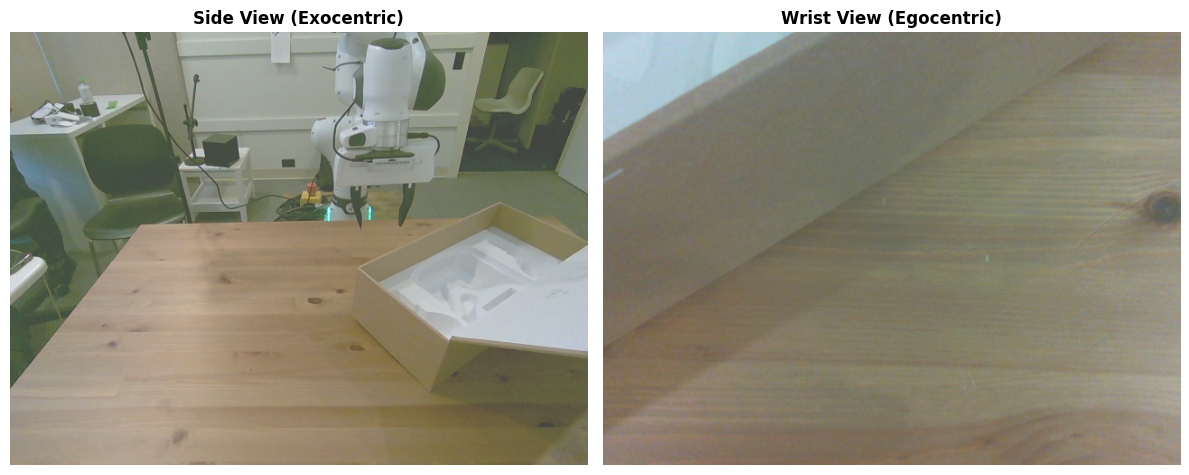


📦 Initializing MolmoAct...
🔄 Loading MolmoAct model: allenai/MolmoAct-7B-D-0812
   This may take a few minutes on first run...
   📥 Loading model weights...


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
def load_example_images() -> Tuple[Image.Image, Image.Image]:
    """Load example images from HuggingFace"""
    print("📥 Loading example images...")

    url1 = "https://huggingface.co/allenai/MolmoAct-7B-D-0812/resolve/main/example_1.png"
    url2 = "https://huggingface.co/allenai/MolmoAct-7B-D-0812/resolve/main/example_2.png"

    headers = {"User-Agent": "python-requests"}

    r1 = requests.get(url1, headers=headers, timeout=30)
    r1.raise_for_status()
    r2 = requests.get(url2, headers=headers, timeout=30)
    r2.raise_for_status()

    img1 = Image.open(BytesIO(r1.content)).convert("RGB")
    img2 = Image.open(BytesIO(r2.content)).convert("RGB")

    print(f"✅ Loaded images: {img1.size} and {img2.size}")

    return img1, img2


def display_images(img1: Image.Image, img2: Image.Image) -> None:
    """Display the example images"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img1)
    axes[0].set_title("Side View (Exocentric)", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(img2)
    axes[1].set_title("Wrist View (Egocentric)", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


def run_demo():
    """
    Run the complete MolmoAct demo
    """
    print("\n" + "=" * 80)
    print("🎬 RUNNING MOLMOACT DEMO")
    print("=" * 80)

    img1, img2 = load_example_images()
    display_images(img1, img2)

    print("\n📦 Initializing MolmoAct...")
    config = MolmoActConfig(
        model_name="allenai/MolmoAct-7B-D-0812",
        torch_dtype="bfloat16",
        max_new_tokens=256,
    )
    model = MolmoActModel(config)

    model.load()

    instruction = "close the box"
    print(f"\n🎯 Task Instruction: '{instruction}'")
    print("🔄 Generating action reasoning...")

    start_time = time.time()
    result = model.generate([img1, img2], instruction)
    inference_time = time.time() - start_time

    print(f"⏱️  Inference time: {inference_time:.2f}s")

    print("\n" + "-" * 60)
    print("📝 GENERATED REASONING:")
    print("-" * 60)
    print(result['text'][:500] + "..." if len(result['text']) > 500 else result['text'])

    print("\n" + "-" * 60)
    print("🔍 PARSED OUTPUTS:")
    print("-" * 60)

    print(f"\n🌊 Depth Tokens: {result['depth'][0][:50]}..." if result['depth'] else "No depth tokens")
    print(f"\n📍 Visual Trace: {result['trace']}")
    print(f"\n🎮 Action (unnormalized): {result['action']}")
    print(f"🎮 Action (raw): {result['action_raw']}")

    print("\n" + "-" * 60)
    print("🎨 VISUALIZATIONS:")
    print("-" * 60)

    visualizer = MolmoActVisualizer()

    if result['trace'] and len(result['trace']) > 0:
        visualizer.plot_trace(
            img1,
            result['trace'][0],
            title=f"Visual Trace for: '{instruction}'"
        )

    if result['action'] and len(result['action']) > 0:
        visualizer.plot_action(
            result['action'][0],
            title=f"Predicted Action for: '{instruction}'"
        )

    print("\n" + "-" * 60)
    print("⚙️  ACTION PROCESSING:")
    print("-" * 60)

    if result['action'] and len(result['action']) > 0:
        processor = ActionProcessor()
        action = np.array(result['action'][0])

        pose_delta = processor.action_to_pose_delta(action)
        print(f"\n📐 Position Delta: {pose_delta['position_delta']}")
        print(f"🔄 Rotation Delta: {pose_delta['rotation_delta']}")
        print(f"✋ Gripper State: {'OPEN' if pose_delta['gripper'] > 0.5 else 'CLOSED'}")

    print("\n" + "=" * 80)
    print("✅ DEMO COMPLETED!")
    print("=" * 80)

    return model, result


print("\n" + "=" * 80)
print("🔬 SECTION 7: ADVANCED FEATURES")
print("=" * 80)

class MolmoActRollout:
    """Rollout controller for continuous action generation"""

    def __init__(
        self,
        model: MolmoActModel,
        action_chunk_size: int = 8,
        smoothing_window: int = 3
    ):
        self.model = model
        self.action_chunk_size = action_chunk_size
        self.smoothing_window = smoothing_window
        self.processor = ActionProcessor()
        self.action_history = []
        self.reset()

    def reset(self):
        """Reset rollout state"""
        self.action_history = []
        self.step_count = 0

    def step(self, images: List[Image.Image], instruction: str) -> Dict:
        """Execute one step of the rollout"""
        result = self.model.generate(images, instruction)

        if result['action'] and len(result['action']) > 0:
            action = np.array(result['action'][0])
            self.action_history.append(action)
            self.step_count += 1

            if len(self.action_history) >= self.smoothing_window:
                smoothed = self.processor.smooth_actions(
                    self.action_history[-self.smoothing_window:],
                    self.smoothing_window
                )[-1]
            else:
                smoothed = action

            result['smoothed_action'] = smoothed
            result['step'] = self.step_count

        return result

    def get_action_statistics(self) -> Dict:
        """Get statistics of collected actions"""
        if not self.action_history:
            return {}

        actions = np.array(self.action_history)

        return {
            "mean": actions.mean(axis=0).tolist(),
            "std": actions.std(axis=0).tolist(),
            "min": actions.min(axis=0).tolist(),
            "max": actions.max(axis=0).tolist(),
            "num_steps": len(self.action_history)
        }


def demonstrate_custom_stats():
    """Demonstrate using custom normalization statistics"""
    print("\n" + "-" * 60)
    print("📐 CUSTOM STATISTICS DEMO")
    print("-" * 60)

    custom_stats = {
        "franka": {
            "mean": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5],
            "std": [0.05, 0.05, 0.05, 0.3, 0.3, 0.3, 0.5],
        },
        "ur5": {
            "mean": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5],
            "std": [0.08, 0.08, 0.08, 0.4, 0.4, 0.4, 0.5],
        }
    }

    processor = ActionProcessor(custom_stats)

    normalized_action = np.array([0.5, -0.3, 0.2, 0.1, -0.1, 0.05, 0.8])

    print("Normalized action:", normalized_action)
    print("\nUnnormalized for different robots:")

    for robot in ["franka", "ur5"]:
        unnorm = processor.unnormalize(normalized_action, key=robot)
        print(f"  {robot}: {unnorm}")


print("\n" + "=" * 80)
print("💡 SECTION 8: TIPS AND BEST PRACTICES")
print("=" * 80)

tips = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                       MolmoAct Best Practices                                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🖼️  IMAGE INPUTS:                                                           ║
║  • Use 2 camera views: side (exocentric) + wrist (egocentric)               ║
║  • Ensure good lighting and clear visibility                                ║
║  • Match camera setup to training distribution (Franka/DROID-like)         ║
║                                                                              ║
║  📝 INSTRUCTIONS:                                                            ║
║  • Keep instructions clear and concise                                       ║
║  • Use action-oriented language ("pick up", "push", "close")                ║
║  • Avoid ambiguous references                                               ║
║                                                                              ║
║  ⚡ PERFORMANCE:                                                              ║
║  • Use bfloat16 for faster inference                                        ║
║  • Batch similar observations when possible                                  ║
║  • Consider vLLM for production deployment                                  ║
║                                                                              ║
║  🔧 FINE-TUNING:                                                             ║
║  • Collect 50-100 demonstrations for new tasks                              ║
║  • Use LoRA for efficient adaptation                                        ║
║  • Include depth perception in training data                                ║
║                                                                              ║
║  ⚠️  SAFETY:                                                                  ║
║  • Always inspect visual traces before execution                            ║
║  • Implement force limits and collision detection                           ║
║  • Test in simulation before real-world deployment                          ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

print(tips)

if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("🤖 MOLMOACT ADVANCED TUTORIAL - MAIN EXECUTION")
    print("=" * 80)

    print("""
    This tutorial provides a comprehensive guide to MolmoAct.

    To run the full demo (requires GPU with ~16GB VRAM):
        model, result = run_demo()

    To just load images and explore:
        img1, img2 = load_example_images()
        display_images(img1, img2)

    For advanced features:
        demonstrate_custom_stats()

    Happy robotics! 🤖
    """)

    model, result = run_demo()

    print("\n📷 Loading and displaying example images...")
    try:
        img1, img2 = load_example_images()
        display_images(img1, img2)
        print("\n✅ Images loaded! Uncomment 'run_demo()' to run full inference.")
    except Exception as e:
        print(f"⚠️ Could not load images: {e}")
        print("This is expected in environments without internet access.")